In [2]:
import pandas as pd
import setup_paths as paths
import data_plotting_func_min_dist as data_plotting
import numpy as np
import math
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams.update({'font.size': 20})

In [3]:
filenames = ['results_eq_object_03s_snr_20_blank_0_new_snr20.pkl',
             'results_eq_object_05s_snr_20_blank_0_new_snr20.pkl',
             'results_eq_object_1s_snr_20_blank_0_new_snr20.pkl',
             'results_eq_object_4s_snr_20_blank_0_new_snr20.pkl']

In [21]:
def calc_tp_mag_lim(df, mag_lim, n=0, min_dist=0, max_dist=1000):
	# print(mag_lim)
	list_mags, list_tpmax, list_n_stations, list_distances, list_azimuths, list_ids = sort_tp_data(
		df, mag_lim, n=n, min_dist=min_dist, max_dist=max_dist)
	y_aves_tp = []
	x_aves_tp = []
	n_stations_tp = []
	azimuths_tp = []
	distances_tp = []
	ids_tp = []
	i = 0
	for i in range(0, len(list_mags)):
		azimuths_tp.append([])
		distances_tp.append([])
		ids_tp.append([])
		if len(list_tpmax[i]) >= 1:
			mean_tp = np.mean(list_tpmax[i])
			std_tp = np.std(list_tpmax[i])
			y_tp = []
			for count, j in enumerate(list_tpmax[i]):
				if (j > mean_tp - 2 * std_tp
						and j < mean_tp + 2 * std_tp):  # and j < 100:
					y_tp.append(math.log(j, 10))
					azimuths_tp[i].append(list_azimuths[i][count])
					distances_tp[i].append(list_distances[i][count])
					# print(list_ids[count])
					# print(ids_tp)
					# print(i, count)
					ids_tp[i].append(list_ids[i][count])
				elif len(list_tpmax[i]) == 1:
					y_tp.append(math.log(j, 10))
					azimuths_tp[i].append(list_azimuths[i][count])
					distances_tp[i].append(list_distances[i][count])
					# print(list_ids[count])
					# print(ids_tp[i])
					# print(i, count)
					ids_tp[i].append(list_ids[i][count])
			x_tp = np.zeros(len(y_tp))
			x_tp = x_tp + list_mags[i]
			if math.isnan(np.median(y_tp)) is False:
				y_aves_tp.append(np.median(y_tp))
				x_aves_tp.append(list_mags[i])
				n_stations_tp.append(list_n_stations[i])
			else:
				azimuths_tp[i] = []
				distances_tp[i] = []
				ids_tp[i] = []

	return x_aves_tp, y_aves_tp, n_stations_tp, azimuths_tp, distances_tp, ids_tp 

In [22]:
def sort_tp_data(df, mag_lim=0, n=0, min_dist=0, max_dist=1000):
	list_mag = []
	list_tpmax = []
	list_n_stations = []
	list_azimuths = []
	list_distances = []
	list_ids = []
	count = 0
	# print(mag_lim, type(mag_lim))
	if type(mag_lim) in [int, float, np.float64]:
		min_mag_lim = mag_lim
		max_mag_lim = 10
	else:
		(min_mag_lim, max_mag_lim) = mag_lim
	for index, row in df.iterrows():
		if (row.eq_mag > min_mag_lim
				and row.eq_mag < max_mag_lim
				and len(row.tp_max) >= n):
			list_mag.append(row.eq_mag)
			list_tpmax.append([])
			list_n_stations.append([])
			list_azimuths.append([])
			list_distances.append([])
			list_ids.append([])
			for d in range(0, len(row.tp_max)):
				if (row.tp_max[d] is not None
						and row.tp_max[d] > 0
						and row.distance_dict[row.tp_max_stations[d]] > min_dist
						and row.distance_dict[row.tp_max_stations[d]] < max_dist):
					list_tpmax[count].append(row.tp_max[d])
					list_n_stations[count].append(row.tp_max_stations[d])
					list_azimuths[count].append(row.azimuth_dict[row.tp_max_stations[d]])
					list_distances[count].append(row.distance_dict[row.tp_max_stations[d]])
					list_ids[count].append(row.eq_id)

			count += 1
	return list_mag, list_tpmax, list_n_stations, list_azimuths, list_distances, list_ids

In [23]:
min_dist = 0
max_dist = 200

In [24]:
list_base_folders = ['/home/earthquakes1/homes/Rebecca/phd/data/2005_2018_global_m5/',
					 '/home/earthquakes1/homes/Rebecca/phd/data/2018_2021_global_m5/',
					 '/home/earthquakes1/homes/Rebecca/phd/data/2019_global_m3/']

# list_base_folders = []

# for folder in subfolders:
#     list_base_folders.append(os.path.join(root_path, folder) + '/')

filenames = ['eq_object_03s_bandpass_01_19_snr_20_blank_0_new.pkl.pkl',
			 'eq_object_05s_bandpass_01_19_snr_20_blank_0_new.pkl',
			 'eq_object_1s_bandpass_01_19_snr_20_blank_0_new.pkl',
			 'eq_object_4s_bandpass_01_19_snr_20_blank_0_new.pkl']

In [25]:
list_mags, list_tpmax, list_n_stations, list_distances, list_azimuths, list_ids = sort_tp_data(
	df, 0, n=1, min_dist=0, max_dist=1000)

In [26]:
list_azimuths

[[108.4689294140896],
 [82.15197226137788],
 [102.60069349279726],
 [107.42817575161531, 108.5418622117498],
 [51.769043605734154,
  51.29397008335626,
  43.82878488308995,
  44.127429870789236,
  53.44058466319464,
  52.860613900752874,
  64.26504989996762,
  62.45124152851046,
  71.38803626174933,
  52.344545392829964,
  47.670647229507246,
  76.63277916142881,
  82.33841617621988,
  91.77508041363346,
  57.979526442812585,
  82.75870885347032,
  63.735280019183435,
  67.95975464573246,
  64.07274776244108,
  85.79831225879282,
  77.19390298144705,
  77.72413449115446,
  83.89578281470607,
  100.07483463108316,
  98.16518509762251,
  90.72569672464253,
  84.50386243114298,
  96.6320438193496,
  78.55901572180746,
  68.98544453490432,
  77.39490863161802,
  85.75525901621421,
  109.07921183902879,
  107.91970968510977,
  109.10261809618824,
  24.792980115170437,
  56.6084141989989,
  45.35269842618317,
  58.5564228275093,
  37.03902115889207,
  76.65143598413684,
  72.63451402701568,


In [27]:
for fn in filenames[0:1]:
    print(fn)
	
    df = pd.read_pickle('/home/earthquakes1/homes/Rebecca/phd/seismo_det/data/results_database_combined_azimuths/results_eq_object_03s_bandpass_01_19_snr_20_blank_0_new.pkl.pkl')

    # can run for multiple (minimum) n_stations and min_dist, but for now just look at all data

    for min_dist in [0]:  # np.arange(0, 51, 10):
        for n_stations in [1]:  # range(0, 6, 1):

            # prepare data
            options = {'n': n_stations, 'min_dist': min_dist, 'max_dist': max_dist}
            x_tp, y_tp, n_stations_tp, aziumths_tp, distances_tp, ids_tp = calc_tp_mag_lim(df, 3., **options)
            # x_pgd, y_pgd = data_plotting.calc_pgd_mag_lim(df, 3., **options)
            # x_tc, y_tc = data_plotting.calc_tc_mag_lim(df, 3., **options)
            # x_iv2, y_iv2 = data_plotting.calc_iv2_mag_lim(df, 3., **options)



eq_object_03s_bandpass_01_19_snr_20_blank_0_new.pkl.pkl


In [28]:
df

,level_0,index,eq_id,eq_mag,eq_mag_type,eq_time,eq_loc,tp_max,tp_max_stations,tc,tc_stations,iv2,iv2_distances,iv2_stations,pgd,pgd_distances,pgd_stations,distance_dict,azimuth_dict
0,0,0,2110129,5.00,MW,20050131_173151,"(-41.6009, 175.838, 19.9)",[0.46069622670091653],[NZ.MRZ.10],[0.7684089259007126],[NZ.MRZ.10],[],[],[],[1.3451628087093107e-06],[106.68083076278864 km],[NZ.MRZ.10],"{'IU.SNZO.00': 102.08314562572458, 'NZ.BFZ.10'...","{'IU.SNZO.00': -71.39814996005346, 'NZ.BFZ.10'..."
1,1,0,2011699,5.30,MW,20050120_185630,"(-41.1222, 174.9773, 39.7)",[0.4266870798499707],[NZ.MRZ.10],[0.562584127820719],[NZ.MRZ.10],[7.506850628317214e-10],[72.07969998851411 km],[NZ.MRZ.10],[6.9082183253613575e-06],[72.07969998851411 km],[NZ.MRZ.10],"{'IU.SNZO.00': 50.273212837431664, 'NZ.MRZ.10'...","{'IU.SNZO.00': -132.33427803852754, 'NZ.MRZ.10..."
2,2,0,2000953,5.00,MW,20050118_092558,"(-41.5413, 175.8527, 21.0)",[1.7511894768723555],[NZ.MRZ.10],[0.49758509486775276],[NZ.MRZ.10],[],[],[],[1.4463676836587083e-06],[100.4879719628321 km],[NZ.MRZ.10],"{'IU.SNZO.00': 101.6008496163856, 'NZ.BFZ.10':...","{'IU.SNZO.00': -75.26438587458226, 'NZ.BFZ.10'..."
3,3,0,2000808,5.20,MW,20050118_083600,"(-41.6055, 175.8911, 9.2)","[1.5581815100094385, 1.1656885463505957]","[NZ.BFZ.10, NZ.MRZ.10]","[0.9134682184264626, 3.5271103669414527]","[NZ.BFZ.10, NZ.MRZ.10]",[],[],[],"[2.2358515086233166e-06, 1.5862808022522566e-06]","[107.05746146962363 km, 108.1752118389166 km]","[NZ.BFZ.10, NZ.MRZ.10]","{'IU.SNZO.00': 104.89522924441958, 'NZ.BFZ.10'...","{'IU.SNZO.00': -71.94018844036243, 'NZ.BFZ.10'..."
4,4,0,1947713,5.00,MW,20050204_091538,"(-37.922, -73.3985, 22.8)","[0.4191753547981261, 0.409403179900639, 0.2719...","[ZW.A401., ZW.A402., ZW.A403., ZW.A404., ZW.A4...","[0.2990792573731559, 0.24328713385773215, 0.29...","[ZW.A401., ZW.A402., ZW.A403., ZW.A404., ZW.A4...","[1.382767357244964e-10, 1.694572163690084e-07,...","[46.52436835522224 km, 45.99021789372439 km, 3...","[ZW.A401., ZW.A402., ZW.A403., ZW.A404., ZW.A4...","[2.9844854382324477e-06, 4.859628472093522e-05...","[46.52436835522224 km, 45.99021789372439 km, 3...","[ZW.A401., ZW.A402., ZW.A403., ZW.A406., ZW.A4...","{'ZW.A401.': 51.769043605734154, 'ZW.A402.': 5...","{'ZW.A401.': 175.7254064462551, 'ZW.A402.': -1..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4432,2318,0,11140120,4.10,mb,20191101_234328,"(-29.1792, -71.8827, 37.04)","[2.1223653960054927, 0.2467675380740236]","[C1.AC04., C1.CO10.]","[2.385423974757786, 0.29058375675459186]","[C1.AC04., C1.CO10.]",[],[],[],"[9.05359705046551e-07, 2.5869818508964764e-05]","[133.8459329456974 km, 41.57949818031772 km]","[C1.AC04., C1.CO10.]","{'C.GO04.': 156.03739863217808, 'C1.AC04.': 13...","{'C.GO04.': 136.81241760481643, 'C1.AC04.': 36..."
4433,2319,0,11139880,5.30,Mww,20191101_152412,"(11.5712, -86.7909, 50.02)","[1.579408618923122, 0.9599298495579663, 1.5285...","[NU.CNGN., NU.CRIN., NU.HERN., NU.NANN.]","[2.4782223144615236, 1.3037756084787688, 1.497...","[NU.CNGN., NU.CRIN., NU.HERN., NU.NANN.]",[],[],[],"[1.0341009384644005e-05, 0.00023046047717655612]","[128.0167604106423 km, 83.56438721336707 km]","[NU.CRIN., NU.NANN.]","{'NU.CARN.00': 153.21529323404573, 'NU.CNGN.':...","{'NU.CARN.00': 107.03038511884024, 'NU.CNGN.':..."
4434,2320,0,11139830,3.55,Mw,20191101_093317,"(36.568833, -117.976, 10.79)","[0.7219045391363624, 0.22270238905129972, 0.37...","[CI.CGO., CI.CWC., NN.DSP., CI.FUR., CI.GRA., ...","[0.22439935379917977, 0.11440021609478028, 0.2...","[CI.CGO., CI.CWC., NN.DSP., CI.FUR., CI.GRA., ...",[],[],[],"[2.1152929761349745e-05, 8.478855296329213e-06...","[15.62630164052065 km, 17.177205341114774 km, ...","[CI.CGO., CI.CWC., NN.DSP., CI.FUR., CI.GRA., ...","{'BK.KARE.00': 137.184039278157, 'BK.KCC.00': ...","{'BK.KARE.00': -88.21273739687454, 'BK.KCC.00'..."
4435,2321,0,11139801,3.20,ML,20191101_070002,"(39.137, -119.6248, 8.2)","[0.17066622598607115, 2.0437194125730938]","[NN.PNT., NN.WAK.]","[0.18412799

In [29]:
#x_tp, y_tp, n_stations_tp, aziumths_tp, distances_tp, ids_tp

In [30]:
for i in range(0, 10):
	if len(aziumths_tp[i]) > 0:
		print(aziumths_tp[i])

[108.4689294140896]
[82.15197226137788]
[102.60069349279726]
[107.42817575161531, 108.5418622117498]
[51.769043605734154, 51.29397008335626, 43.82878488308995, 44.127429870789236, 53.44058466319464, 52.860613900752874, 64.26504989996762, 62.45124152851046, 71.38803626174933, 52.344545392829964, 47.670647229507246, 76.63277916142881, 82.33841617621988, 91.77508041363346, 57.979526442812585, 82.75870885347032, 63.735280019183435, 67.95975464573246, 64.07274776244108, 85.79831225879282, 77.19390298144705, 77.72413449115446, 83.89578281470607, 100.07483463108316, 98.16518509762251, 90.72569672464253, 84.50386243114298, 96.6320438193496, 78.55901572180746, 77.39490863161802, 85.75525901621421, 109.07921183902879, 107.91970968510977, 109.10261809618824, 24.792980115170437, 56.6084141989989, 45.35269842618317, 58.5564228275093, 37.03902115889207, 76.65143598413684, 72.63451402701568, 79.1452244485838, 98.67310374470763, 78.31165167952904, 87.20778016094854, 109.32174931501415, 73.644209866245

In [31]:
all_az = np.concatenate(aziumths_tp)

(array([ 47., 108., 182., 312., 395., 443., 462., 448., 526., 555., 559.,
        600., 647., 621., 447., 494., 480., 526., 532., 468., 472., 543.,
        567., 505., 559., 550., 514., 476., 540., 595., 543., 516., 475.,
        484., 479., 480., 436., 465., 486., 516., 450., 471., 430., 460.,
        370., 282., 282., 254., 223., 250., 208., 208., 231., 226., 255.,
        231., 226., 229., 201., 156., 132., 111., 104., 100.,  92.,  70.,
         76.,  62.,  52.,  43.,  51.,  41.,  46.,  40.,  42.,  31.,  34.,
         32.,  39.,  25.]),
 array([  0.71878578,   3.20911084,   5.69943589,   8.18976094,
         10.680086  ,  13.17041105,  15.6607361 ,  18.15106115,
         20.64138621,  23.13171126,  25.62203631,  28.11236137,
         30.60268642,  33.09301147,  35.58333653,  38.07366158,
         40.56398663,  43.05431169,  45.54463674,  48.03496179,
         50.52528685,  53.0156119 ,  55.50593695,  57.99626201,
         60.48658706,  62.97691211,  65.46723717,  67.95756222,
      

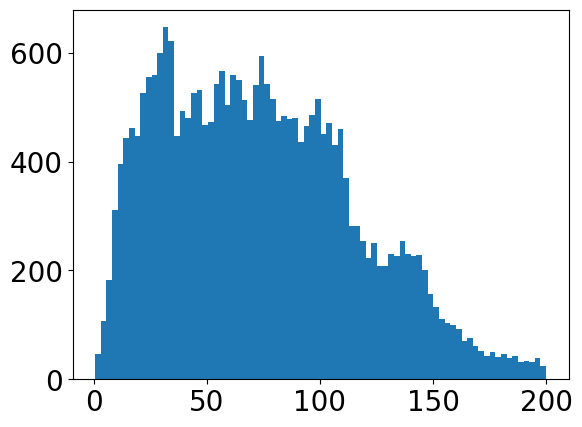

In [35]:
plt.hist(all_az, bins=80)

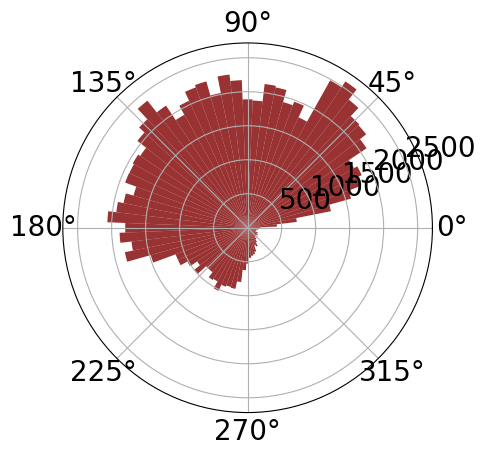

In [32]:
import numpy as np
import matplotlib.pyplot as plt

N = 80
bottom = 0
max_height = 4

theta = np.linspace(0.0, 2 * np.pi, N, endpoint=False)
n, bins = np.histogram(all_az, bins=N)
radii = max_height*n
width = (2*np.pi) / N

ax = plt.subplot(111, polar=True)
bars = ax.bar(theta, radii, width=width, bottom=bottom)

# Use custom colors and opacity
for r, bar in zip(radii, bars):
    bar.set_facecolor(plt.cm.jet(r / 10.))
    bar.set_alpha(0.8)

plt.show()

In [76]:
n_stations_tp_count = []
for n_sta in n_stations_tp:
	n_stations_tp_count.append(len(n_sta))

NameError: name 'n_stations_tp_count' is not defined

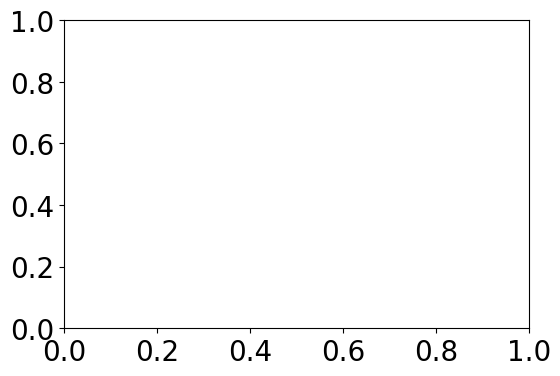

In [12]:
fig, axs = plt.subplots(1, 1, figsize=(6, 4))

ax = axs
ax.scatter(n_stations_tp_count, y_tp)
# axs[0].set_yscale('log')
ax.set_xlabel('Number of stations')
ax.set_ylabel('tp_max')

m, b = np.polyfit(n_stations_tp_count, y_tp, 1)
print(m, b)
ax.plot(np.array(n_stations_tp_count), m * np.array(n_stations_tp_count) + b, color='red')


In [ ]:
plt.scatter(x_tp, n_stations_tp_count, color='blue', label='TP')

KeyboardInterrupt: 

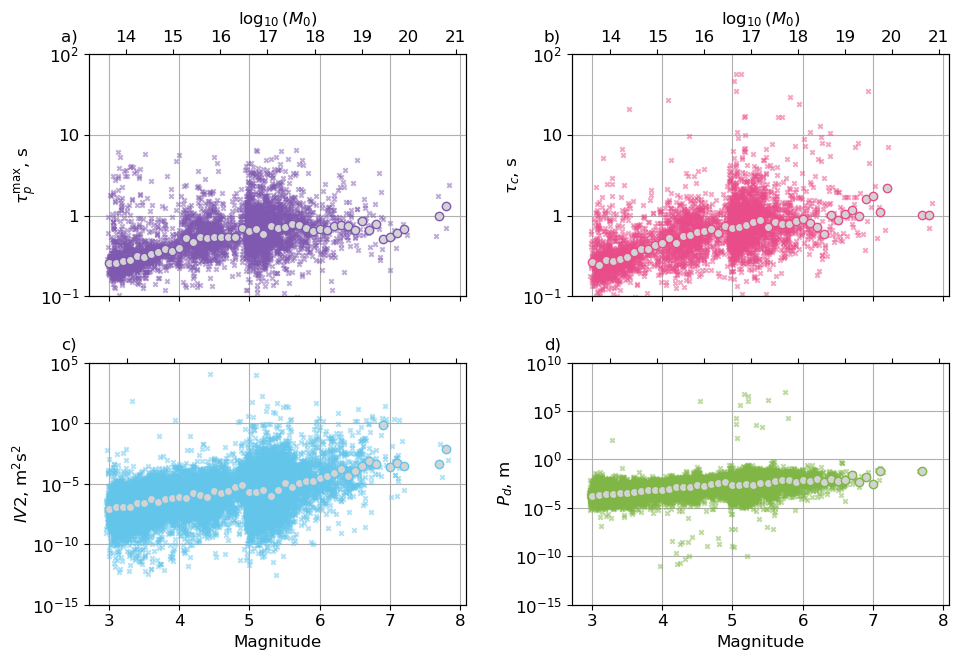

In [48]:
            # make scatter plots of data without best fit lines
            data_plotting.plot_data_subplots([x_tp, x_iv2, x_tc, x_pgd],
                                             [y_tp, y_iv2, y_tc, y_pgd],
                                             ['tp', 'iv2', 'tc', 'pgd'],
                                             f,
                                             n=n_stations,
                                             min_dist=min_dist, max_dist=max_dist,
                                             save=True, show=False)
            data_plotting.plot_data_subplots_grey([x_tp, x_iv2, x_tc, x_pgd],
                                                  [y_tp, y_iv2, y_tc, y_pgd],
                                                  ['tp', 'iv2', 'tc', 'pgd'],
                                                  f,
                                                  n=n_stations,
                                                  min_dist=min_dist, max_dist=max_dist,
                                                  save=True, show=False)

            # predominant period
            # define empty lists to store the results
            gradt, intercept, gradt_std, intercept_std = [], [], [], []
            pearson = []
            spearman = []
            spearman_p = []
            n_l = []

            # loop over magnitudes and calculate statistical values for each. append to lists just defined.
            for mag_lim in data_plotting.magnitudes:
                x, y = data_plotting.calc_tp_mag_lim(df, mag_lim, **options)
                output = data_plotting.calc_opt(x, y,
                                                gradt,
                                                intercept,
                                                gradt_std,
                                                intercept_std,
                                                pearson,
                                                spearman,
                                                spearman_p,
                                                n_l)
                gradt, intercept, gradt_std, intercept_std, pearson, spearman, spearman_p, n = output
            tp_params = [gradt, gradt_std, intercept, intercept_std, 'tp']

            # average period
            # define empty lists to store the results
            gradt, intercept, gradt_std, intercept_std = [], [], [], []
            pearson = []
            spearman = []
            spearman_p = []
            n_l = []
            # loop over magnitudes and calculate statistical values for each. append to lists just defined.
            for mag_lim in data_plotting.magnitudes:
                x, y = data_plotting.calc_tc_mag_lim(df, mag_lim, **options)
                output = data_plotting.calc_opt(x, y,
                                                gradt,
                                                intercept,
                                                gradt_std,
                                                intercept_std,
                                                pearson,
                                                spearman,
                                                spearman_p,
                                                n_l)
                gradt, intercept, gradt_std, intercept_std, pearson, spearman, spearman_p, n = output
            tc_params = [gradt, gradt_std, intercept, intercept_std, 'tc']

            # peak ground displacement
            # define empty lists to store the results
            gradt, intercept, gradt_std, intercept_std = [], [], [], []
            pearson = []
            spearman = []
            spearman_p = []
            n_l = []

            # loop over magnitudes and calculate statistical values for each. append to lists just defined.
            for mag_lim in data_plotting.magnitudes:
                x, y = data_plotting.calc_pgd_mag_lim(df, mag_lim, **options)
                output = data_plotting.calc_opt(x, y,
                                                gradt,
                                                intercept,
                                                gradt_std,
                                                intercept_std,
                                                pearson,
                                                spearman,
                                                spearman_p,
                                                n_l)
                gradt, intercept, gradt_std, intercept_std, pearson, spearman, spearman_p, n = output
            pgd_params = [gradt, gradt_std, intercept, intercept_std, 'pgd']

            # iv2
            # define empty lists to store the results
            gradt, intercept, gradt_std, intercept_std = [], [], [], []
            pearson = []
            spearman = []
            spearman_p = []
            n_l = []
            # loop over magnitudes and calculate statistical values for each. append to lists just defined.
            for mag_lim in data_plotting.magnitudes:
                x, y = data_plotting.calc_iv2_mag_lim(df, mag_lim, **options)
                output = data_plotting.calc_opt(x, y,
                                                gradt,
                                                intercept,
                                                gradt_std,
                                                intercept_std,
                                                pearson,
                                                spearman,
                                                spearman_p,
                                                n_l)
                gradt, intercept, gradt_std, intercept_std, pearson, spearman, spearman_p, n = output
            iv2_params = [gradt, gradt_std, intercept, intercept_std, 'iv2']

            # do plotting with best-fit lines
            data_plotting.plot_data_subplots_line([x_tp, x_iv2, x_tc, x_pgd],
                                                  [y_tp, y_iv2, y_tc, y_pgd],
                                                  ['tp', 'iv2', 'tc', 'pgd'],
                                                  f,
                                                  tp_params,
                                                  iv2_params,
                                                  tc_params,
                                                  pgd_params,
                                                  n=n_stations,
                                                  min_dist=min_dist, max_dist=max_dist,
                                                  save=True, show=False, hyp=False)
